# Building a host galaxy with `slicersim.scene.host.Host`

This notebook shows how to build a `Host` structured background (a spatially
extended source, such as the galaxy hosting a supernova), and how to change
its parameters, such as the shape of the output cube or the position angle of
the galaxy.

## 1. What is a `Host`?

A `Host` is a scene element whose flux is not a single spectrum but a
**datacube**: at every wavelength, the spectrum is modulated by a 2D
spatial profile. This spatial profile is a Sersic profile (`get_sersic_profile`),
parametrized by an effective radius, a Sersic index, an ellipticity and a
position angle, and rendered onto a pixel grid of a given `shape` and
`pixel_scale`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from slicersim.scene.host import Host, get_sersic_profile

## 2. Building a host cube from a reference spectrum

`Host.from_sersic_and_spectrum` builds a `Host` from a reference spectrum
(`lbda`, `flux`), rescaled to a given magnitude `mag` in a given `band`, combined with
a Sersic spatial profile.

In [2]:
# a flat reference spectrum
lbda_ref = np.linspace(3000, 10000, 500)
flux_ref = np.ones_like(lbda_ref) * 1e-15

host = Host.from_sersic_and_spectrum(
    lbda_ref, flux_ref, mag=20, band="sdssr",
    r_eff=0.5, n=1.0, ellip=0.3, theta=30,
    pixel_scale=0.1, shape=(40, 40), oversample=4,
)
host

`get_spectrum` returns the wavelength array and the corresponding datacube,
of shape `(len(lbda), ny, nx)`.

In [3]:
lbda = np.linspace(4000, 9000, 100)
lbda, cube = host.get_spectrum(lbda=lbda)
cube.shape

(100, 40, 40)

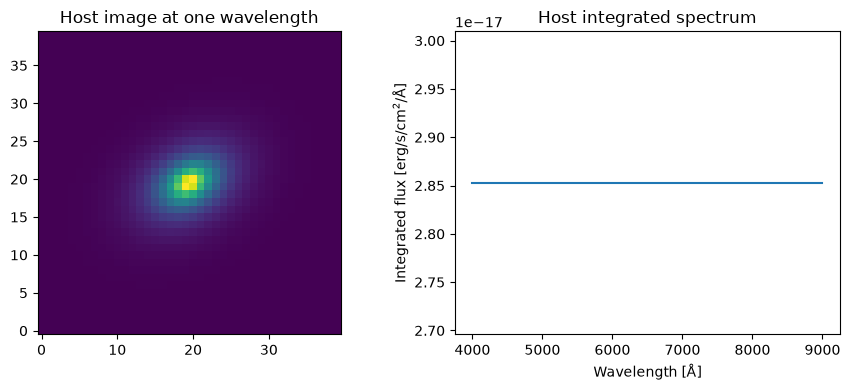

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(cube[len(lbda) // 2], origin="lower")
axes[0].set_title("Host image at one wavelength")

axes[1].plot(lbda, cube.sum(axis=(1, 2)))
axes[1].set_xlabel("Wavelength [Å]")
axes[1].set_ylabel("Integrated flux [erg/s/cm$^2$/Å]")
axes[1].set_title("Host integrated spectrum")

fig.tight_layout()
plt.show()

## 3. Changing the shape of the output cube

Like any scene element, a `Host` can be updated in place with `update()`.
This is useful, e.g., to match the spatial sampling of a given IFU or detector.
Note that `shape` is given as `(nx, ny)`, while the cube is `(nlbda, ny, nx)`.

In [5]:
host.update(shape=(60, 30), pixel_scale=0.05)

lbda, cube_reshaped = host.get_spectrum(lbda=lbda)
cube_reshaped.shape

(100, 30, 60)

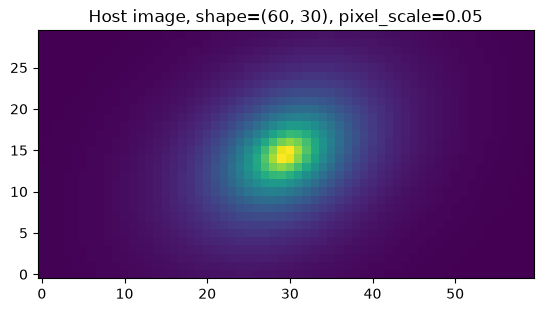

In [6]:
fig, ax = plt.subplots()
ax.imshow(cube_reshaped[len(lbda) // 2], origin="lower")
ax.set_title("Host image, shape=(60, 30), pixel_scale=0.05")
plt.show()

## 4. Changing the position angle and ellipticity of the galaxy

`theta` sets the position angle of the Sersic profile (in degrees, following astropy's
convention: measured counterclockwise from the +x axis) and `ellip` sets its
ellipticity, `1 - b/a`. Both can be changed with `update()` without rebuilding
the `Host` from scratch.

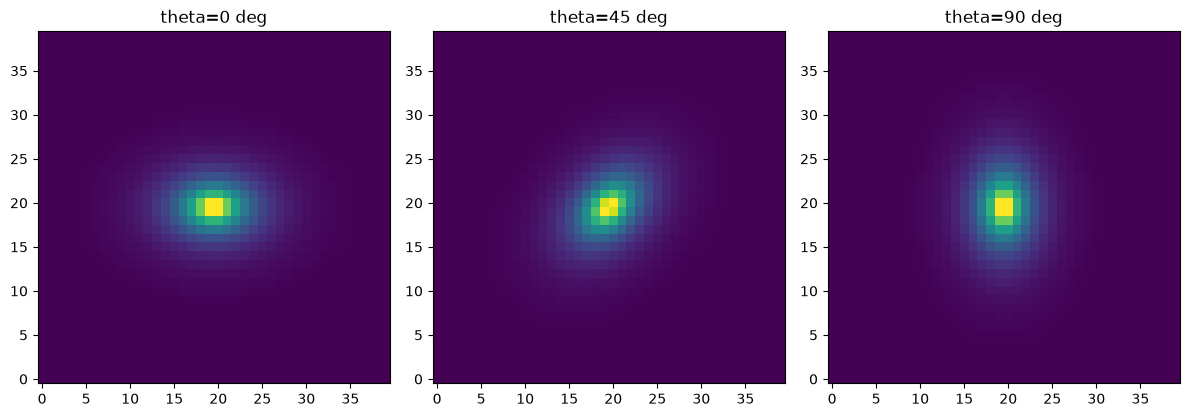

In [7]:
host.update(shape=(40, 40), pixel_scale=0.1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, theta in zip(axes, [0, 45, 90]):
    host.update(theta=theta)
    _, cube_theta = host.get_spectrum(lbda=lbda)
    ax.imshow(cube_theta[len(lbda) // 2], origin="lower")
    ax.set_title(f"theta={theta} deg")

fig.tight_layout()
plt.show()

## 5. Exploring the spatial profile with `get_sersic_profile`

The lower-level `get_sersic_profile` function renders a single, flux-normalized
Sersic image. It is useful to explore how `r_eff`, `n` and `ellip` shape the
galaxy, independently of any spectrum.

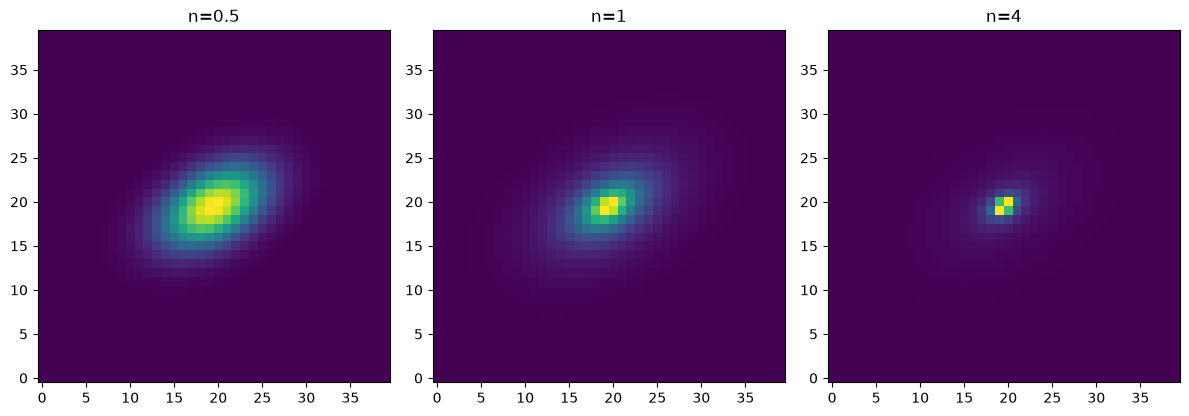

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, n in zip(axes, [0.5, 1, 4]):
    profile = get_sersic_profile(r_eff=0.5, n=n, ellip=0.4, theta=30,
                                  pixel_scale=0.1, shape=(40, 40))
    ax.imshow(profile, origin="lower")
    ax.set_title(f"n={n}")

fig.tight_layout()
plt.show()